In [15]:
import torch
from torch import nn
# nn contains all the building blocks for neural networks
import matplotlib.pyplot as plt
print(torch.__version__)

2.7.1+cu118


In [16]:
weight = 0.7
bias = 0.3

# creating some data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
print(f"X: {X[:10]} \n y: {y[:10]}")

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 
 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


### Splitting the data in train and test

In [17]:
train_set = int(0.8 * len(X))
X_train, y_train = X[:train_set], y[:train_set]
X_test, y_test = X[train_set:], y[train_set:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [18]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")


    plt.legend(prop={"size": 14})

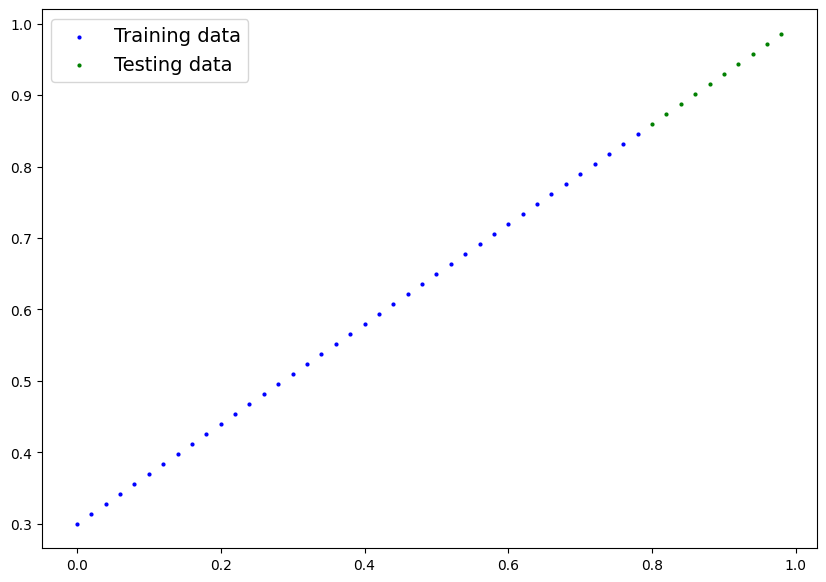

In [19]:
plot_predictions()

In [108]:
# Build the linear regression model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float32))
        
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float32))
        
    # Forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- 'x' is the input data
        return self.weights * x + self.bias # linear regression formula
        
# torch.nn -> contains all the building blocks for computational graphs and neural networks

# torch.nn.Parameter -> a kind of Tensor that is automatically registered as a parameter when assigned as
# a module attribute. Parameters are tensors that are considered as module parameters and will be returned
# when you call model.parameters() and will appear in the list of parameters of the model.

# torch.nn.Module -> a base class for all neural network modules. 
# It provides a lot of functionality for free, such as parameter management, moving the model to GPU, etc.

# torch.optim -> contains all the optimization algorithms (e.g., SGD, Adam, etc.) that can be used to update the parameters of the model based on the computed gradients.

# def forward() -> defines the forward pass of the model. It takes input data and returns the output of the model.

In [31]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])

### Checking model parameters

In [109]:
# create a random seed
torch.manual_seed(42)

# create an instance of the model
model_0 = LinearRegressionModel()

# print out the parameters of the model
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [110]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using torch.inference_mode()

In [111]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [112]:
with torch.inference_mode():
    y_preds = model_0(X_test)
    
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [113]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

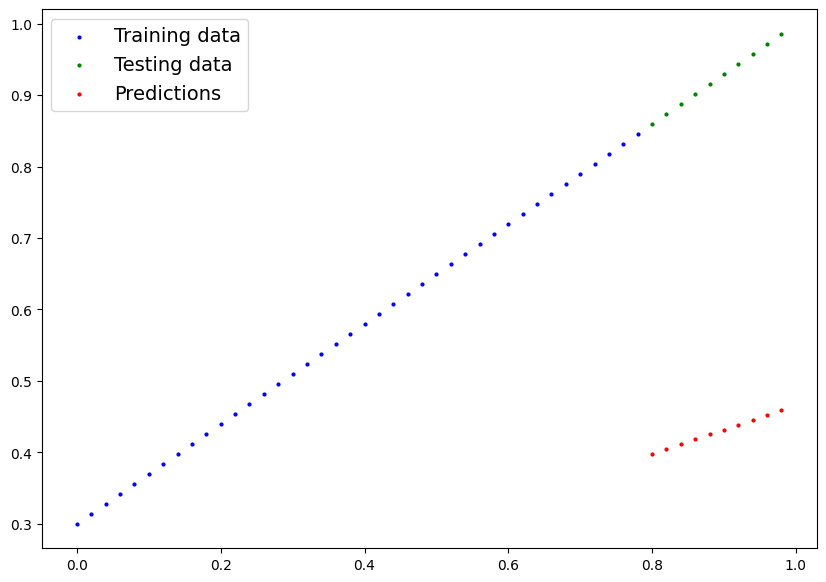

In [114]:
plot_predictions(predictions=y_preds)

In [115]:
# create a loss function
loss_fn = nn.L1Loss()

# create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [120]:
epochs = 3
loss = None
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()
    
    # 1. forward pass
    y_pred = model_0(X_train)
    
    # 2. calculate the loss
    loss = loss_fn(y_pred, y_train)
    
    # 3. optimzer zero grad
    optimizer.zero_grad()
    
    # 4. perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()
    
    # 5. perform gradient descent or update the weights
    optimizer.step()
    
    # Testing
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 2 == 0:    
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")   
        # print the model state dict
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.0021323717664927244 | Test loss: 0.004065275192260742
OrderedDict([('weights', tensor([0.6912])), ('bias', tensor([0.3038]))])
Epoch: 2 | Loss: 0.0014518328243866563 | Test loss: 0.0018701612716540694
OrderedDict([('weights', tensor([0.6947])), ('bias', tensor([0.3028]))])


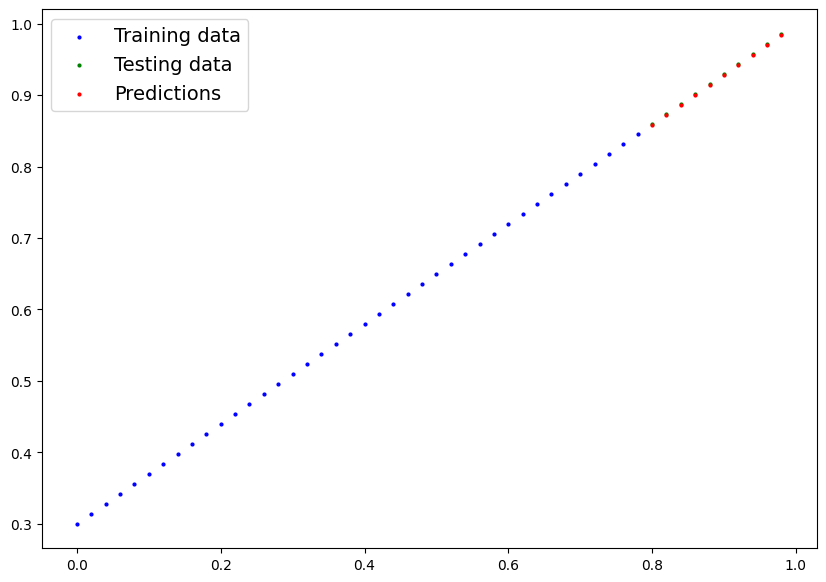

In [121]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
    
plot_predictions(predictions=y_preds_new)